# Business Problem

SCCU tries to optimize logistics by transitioning customers selling below a specific
annual volume to an Alternate Route to Market (ARTM).There is a 400 gallons volume threshold to distinguish between the direct delivery route and ARTM. However, misclassification with existing thresholds can lead
to missed opportunities for revenue expansion and weakened customer relationships. SCCU is looking for a more cost-efficient strategy for optimizing logistics which is driving operational efficiency and more revenues.

By leveraging advanced analytics, SCCU can ensure that high-growth accounts remain
on direct delivery routes, sustaining their full revenue potential while optimizing logistical
efficiency by switching low-growth ones to ARTM. The analysis will focus on two key
customer segments.
• Local Market Partners or customers who buy only fountain drinks and no CO2, cans, or bottles.
• All customers regardless of whether they are local market partners or not, and includes those purchasing CO2, cans, bottles, or fountain drinks.

# Requirement

The analysis will focus on classifying which customers must be included in ARTM or Direct route, and which volume threshold would be optimal to decide for the classification.

The analysis will focus on two key customer segments.

1st Group: This group includes all customers, regardless of whether they are local market partners or not, and includes those purchasing CO2, cans, bottles, or fountain drinks.

2nd Group: Local Market Partners that buy fountains only: Customers who buy only fountain drinks and no CO2, cans, or bottles.

# Business Questions

1. What factors or characteristics distinguish customers with annual sales exceeding the determined volume threshold from those below this threshold?

2. How can SCCU uses historical sales data, or other Customer Characteristics to predict which ARTM customers have the potential to grow beyond the volume threshold annually?

3. How can these insights be integrated into the routing strategy to support long-term growth while maintaining logistical efficiency?

4. What levers can be employed to accelerate volume and share growth at growth-ready, high-potential customers?

# Description of the Data

- Customer Number: Unique identifier for each outlet/store

- Primary Group Number: Common identifier for subparts of stores/outlets. Multiple customer numbers can belong to same primary group indicating they are part of chain.

- Frequent Order Type: Most common type of ordering platform like online, through sales rep, EDI, call center.

The ordering types are:

MYCOKE LEGACY: Old digital ordering platform.

EDI: Orders places via Electronic Data Interchange, bottler sales data is fed directly into retailer system which generates payments to bottlers.

CALL CENTER: Customers placing orders via call center.

SALES REP: Sales representative enters customer orders.

MYCOKE 360: New digital ordering platform launched in summer 2024.

OTHER: Less common methods of ordering

- First Delivery Date: Date of first delivery to customer. This also gives age and longevity of the customer.

- On Boarding Date: Date SCCU signed contract with customer

- Cold Drink Channel: Type of channel the customer belongs to: dining, govt education, eat/drinking, sports venue, special events customer, etc

- Trade Channel: Detailed channel classification - 1 level down from cold drink channel. Example: if a customer belongs to dining channel, are they quick service restaurant or Fine-dining restaurant?

- Sub Trade Channel: Further classification from cold drink channel. 2 levels down from cold drink channel.

- Local Market Partner: Local market customer indicator (T/F)

- CO2 Customer: Boolean indicator if the customer purchases CO2 products(T/F). This is also important to understand the growth of customer with Swire.

- Zip Code: Zip code of the customer. All are randomized and from EAST USA.

- Ordered Cases: Number of cases ordered by the customer.

- Loaded Cases: Number of cases loaded for delivery.

- Delivered Cases: Number of cases delivered to the customer.

- Ordered Gallons: Number of gallons ordered by the customer.

- Loaded Gallons: Number of gallons loaded for delivery.

- Delivered Gallons: Number of gallons actually delivered to the customer.

- Transaction Date: Date of customer's transaction.

- Year: Year of the particular transaction.

- Week: Week number of the year when the transaction occurred.

- Vol Range: Specifies the annual purchase volume range by the customer(in specific channel). Example: "0-149", "1350+"

- Applicable to: Defines the category of the product. Example: Fountain, CO2, Bottles and Cans.

- Median Delivery Cost: Median cost of delivery to Swire for the respective category

- Cost Unit: Unit of measurement. Fountain drinks are measured per gallon while bottles and cans are measures per case.

**Note**:

1. One standard physical case is equal to 1 gallon, allowing for summing cases and gallons directly.

2. Negative delivered volume is considered as a return.

# Data Setup

## Import libraries

In [58]:
#!pip install pandas numpy matplotlib seaborn scikit-learn statsmodels


import pandas as pd
import numpy as np


# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
#from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split


# to impute NA's
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import classification_report, confusion_matrix,accuracy_score,roc_auc_score, roc_curve


# DV
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Analysis
import scipy.stats as stats


# Time-Series Modeling
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# Warnings
import warnings
warnings.filterwarnings("ignore")


In [160]:
#%pip install xgboost
#%pip install shap

## Load Data

In [3]:

profile_df = pd.read_csv("customer_profile.csv")

delivery_cost_df = pd.read_excel("delivery_cost_data1.xlsx")

trans_df = pd.read_csv("transactional_data.csv")

address_df = pd.read_csv("customer_address_zip.csv")


In [4]:
# customer profile df
# Factorizing categorical columns in profile_df

categorical_cols = [
    "FREQUENT_ORDER_TYPE",
    "COLD_DRINK_CHANNEL",
    "TRADE_CHANNEL",
    "SUB_TRADE_CHANNEL",
    "LOCAL_MARKET_PARTNER",
    "CO2_CUSTOMER"
]

for col in categorical_cols:
    profile_df[col] = profile_df[col].astype("category")

# Structure and summary after factorization
print(profile_df.info())  
print(profile_df.describe(include="all"))  


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30478 entries, 0 to 30477
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   CUSTOMER_NUMBER       30478 non-null  int64   
 1   PRIMARY_GROUP_NUMBER  12282 non-null  float64 
 2   FREQUENT_ORDER_TYPE   30478 non-null  category
 3   FIRST_DELIVERY_DATE   30478 non-null  object  
 4   ON_BOARDING_DATE      30478 non-null  object  
 5   COLD_DRINK_CHANNEL    30478 non-null  category
 6   TRADE_CHANNEL         30478 non-null  category
 7   SUB_TRADE_CHANNEL     30478 non-null  category
 8   LOCAL_MARKET_PARTNER  30478 non-null  category
 9   CO2_CUSTOMER          30478 non-null  category
 10  ZIP_CODE              30478 non-null  int64   
dtypes: category(6), float64(1), int64(2), object(2)
memory usage: 1.3+ MB
None
        CUSTOMER_NUMBER  PRIMARY_GROUP_NUMBER FREQUENT_ORDER_TYPE  \
count      3.047800e+04          12282.000000               30478 

In [5]:
# trans_df
# Factorizing categorical columns in trans_df
categorical_cols_trans = ["YEAR", "ORDER_TYPE"]

for col in categorical_cols_trans:
    trans_df[col] = trans_df[col].astype("category")

# Structure and summary
print(trans_df.info())
print(trans_df.describe(include="all"))

# Number of unique levels in the YEAR column (equivalent to nlevels in R)
print(f"Number of levels in YEAR: {trans_df['YEAR'].nunique()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1045540 entries, 0 to 1045539
Data columns (total 11 columns):
 #   Column             Non-Null Count    Dtype   
---  ------             --------------    -----   
 0   TRANSACTION_DATE   1045540 non-null  object  
 1   WEEK               1045540 non-null  int64   
 2   YEAR               1045540 non-null  category
 3   CUSTOMER_NUMBER    1045540 non-null  int64   
 4   ORDER_TYPE         1034409 non-null  category
 5   ORDERED_CASES      1045540 non-null  float64 
 6   LOADED_CASES       1045540 non-null  float64 
 7   DELIVERED_CASES    1045540 non-null  float64 
 8   ORDERED_GALLONS    1045540 non-null  float64 
 9   LOADED_GALLONS     1045540 non-null  float64 
 10  DELIVERED_GALLONS  1045540 non-null  float64 
dtypes: category(2), float64(6), int64(2), object(1)
memory usage: 73.8+ MB
None
       TRANSACTION_DATE          WEEK       YEAR  CUSTOMER_NUMBER  \
count           1045540  1.045540e+06  1045540.0     1.045540e+06   
uniqu

In [6]:
# First 10 rows
#trans_df.head(10)

# First 5 rows (default)
trans_df.head()

# Last 6 rows
#trans_df.tail(6)


,TRANSACTION_DATE,WEEK,YEAR,CUSTOMER_NUMBER,ORDER_TYPE,ORDERED_CASES,LOADED_CASES,DELIVERED_CASES,ORDERED_GALLONS,LOADED_GALLONS,DELIVERED_GALLONS
0,1/5/2023,1,2023,501202893,MYCOKE LEGACY,1.0,1.0,1.0,90.0,90.0,90.0
1,1/6/2023,1,2023,500264574,MYCOKE LEGACY,12.5,12.5,12.5,0.0,0.0,0.0
2,1/9/2023,2,2023,501174701,MYCOKE LEGACY,2.0,2.0,2.0,0.0,0.0,0.0
3,1/11/2023,2,2023,600586532,SALES REP,18.0,16.0,16.0,2.5,2.5,2.5
4,1/17/2023,3,2023,501014325,SALES REP,29.0,29.0,29.0,0.0,0.0,0.0


In [7]:
# Number of rows/observations
trans_df.shape[0]


1045540

In [8]:
# Number of columns
trans_df.shape[1]

11

In [9]:
# delivery cost df

# Column names
delivery_cost_df.columns.tolist()



['Cold Drink Channel',
 'Vol Range',
 'Applicable To',
 'Median Delivery Cost',
 'Cost Type']

In [10]:
# Number of rows
print(delivery_cost_df.shape[0])

# Number of columns
print(delivery_cost_df.shape[1])


160
5


In [11]:
# Convert columns to categorical(factors)
delivery_cost_df['Cold Drink Channel'] = delivery_cost_df['Cold Drink Channel'].astype('category')
delivery_cost_df['Applicable To'] = delivery_cost_df['Applicable To'].astype('category')
delivery_cost_df['Cost Type'] = delivery_cost_df['Cost Type'].astype('category')


In [12]:
# Structure / Data types
delivery_cost_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Cold Drink Channel    160 non-null    category
 1   Vol Range             160 non-null    object  
 2   Applicable To         160 non-null    category
 3   Median Delivery Cost  160 non-null    float64 
 4   Cost Type             160 non-null    category
dtypes: category(3), float64(1), object(1)
memory usage: 3.7+ KB


In [13]:
#address_df

# First 10 rows
address_df.head(5)


,zip,full address
0,71018,"71018,Cotton Valley,Louisiana,LA,Webster,119,3..."
1,71021,"71021,Cullen,Louisiana,LA,Webster,119,32.9721,..."
2,71023,"71023,Doyline,Louisiana,LA,Webster,119,32.49,-..."
3,71024,"71024,Dubberly,Louisiana,LA,Webster,119,32.519..."
4,71039,"71039,Heflin,Louisiana,LA,Webster,119,32.447,-..."


In [14]:
# Number of rows
print(address_df.shape[0])

# Number of columns (if needed)
print(address_df.shape[1])


1801
2


In [15]:
# Structure/datatypes

address_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1801 entries, 0 to 1800
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   zip           1801 non-null   int64 
 1   full address  1801 non-null   object
dtypes: int64(1), object(1)
memory usage: 28.3+ KB


### Total number of customers, total transactions per customer

-   Total number of customers

-   Total volume of cases

-   Total volume of gallons

-   Total Transactions: cases + gallons (for each customer)

In [16]:
# View the first few rows of the dataset
#trans_df.head()


In [17]:
# Number of unique customers
num_unique_customers = trans_df['CUSTOMER_NUMBER'].nunique()
print("Number of unique customers:", num_unique_customers)


Number of unique customers: 30322


In [18]:
# Total number of cases, gallons, and transactions per customer

# Group by customer and calculate total ordered cases, gallons, and transactions
customer_transactions = trans_df.groupby('CUSTOMER_NUMBER').agg(
    Total_Ordered_Cases=('ORDERED_CASES', 'sum'),
    Total_Ordered_Gallons=('ORDERED_GALLONS', 'sum')
).reset_index()

# Add total transactions column (cases + gallons)
customer_transactions['Total_Transactions'] = (
    customer_transactions['Total_Ordered_Cases'] +
    customer_transactions['Total_Ordered_Gallons']
)

# Sort by highest total transactions
customer_transactions = customer_transactions.sort_values(by='Total_Transactions', ascending=False)

# Display top 10
customer_transactions.head(10)


,CUSTOMER_NUMBER,Total_Ordered_Cases,Total_Ordered_Gallons,Total_Transactions
9288,501267499,835641.7738,72.5,835714.2738
28925,600573998,779253.0000,0.0,779253.0000
26959,600265975,471362.0000,652.5,472014.5000
21428,600064039,349237.6656,0.0,349237.6656
3180,500733119,308142.0000,0.0,308142.0000
25193,600252509,275412.0000,0.0,275412.0000
30222,600686566,271243.5000,0.0,271243.5000
26340,600260313,267055.0810,0.0,267055.0810
30190,600686118,253788.2500,0.0,253788.2500
26548,600261951,233790.0000,0.0,233790.0000


In [19]:

# Overall cases, gallons, and transactions with SCCU

# Summarize total across all customers
total_summary = {
    'Total_Cases': trans_df['ORDERED_CASES'].sum(),
    'Total_Gallons': trans_df['ORDERED_GALLONS'].sum()
}
total_summary['Total_Transactions'] = total_summary['Total_Cases'] + total_summary['Total_Gallons']

# Display
print("Total Summary:", total_summary)


Total Summary: {'Total_Cases': 28074470.424968, 'Total_Gallons': 10323336.552258004, 'Total_Transactions': 38397806.977226004}


In [20]:
# Get the earliest and latest transaction dates with SCCU

# Convert TRANSACTION_DATE to datetime format
trans_df['TRANSACTION_DATE'] = pd.to_datetime(trans_df['TRANSACTION_DATE'], format="%m/%d/%Y", errors='coerce')


max_date = trans_df['TRANSACTION_DATE'].max()
min_date = trans_df['TRANSACTION_DATE'].min()

# Display results
print("Earliest transaction date:", min_date)
print("Latest transaction date:", max_date)


Earliest transaction date: 2023-01-01 00:00:00
Latest transaction date: 2024-12-31 00:00:00


In the span of 2 years (1/1/2023 to 12/31/2024), SCCU had 30322 customers with a total of 28,074,470 transacted cases and a total of transacted 10,323,337 gallons (38,397,807 total cases and gallons).

## Transaction History

### Total Annual Purchase Volume

Since the transactional dataset has data aggregated by transaction date and not by order ID, we need to ensure that the total annual purchased volume for each customer is accurately calculated. Since ordered, loaded, and delivered cases/gallons appear on separate dates, our best measure of actual customer purchase volume is DELIVERED volume.

The TOTAL ACTUAL DELIVERY VOLUME to the customer is:

Total Volume = Total No. of Ordered Cases + Total No. of Ordered Gallons, for each year.

(1 physical case = 1 gallon, sum them up directly).

In [21]:


# Ensure TRANSACTION_DATE is in datetime format
trans_df['TRANSACTION_DATE'] = pd.to_datetime(trans_df['TRANSACTION_DATE'], format="%m/%d/%Y", errors='coerce')

# Create the transaction history summary
trans_history = trans_df.groupby('CUSTOMER_NUMBER').agg(
    FIRST_TRANSACTION_DATE=('TRANSACTION_DATE', 'min'),
    LAST_TRANSACTION_DATE=('TRANSACTION_DATE', 'max'),
    TRANS_COUNT=('TRANSACTION_DATE', 'count')
).reset_index()

# Compute additional fields
trans_history['TRANS_DAYS'] = (trans_history['LAST_TRANSACTION_DATE'] - trans_history['FIRST_TRANSACTION_DATE']).dt.days + 1

# Filter and compute transaction count and volumes by year
trans_df['YEAR'] = trans_df['TRANSACTION_DATE'].dt.year

# Group calculations per customer and merge with the base
yearly_summary = trans_df.groupby(['CUSTOMER_NUMBER', 'YEAR']).agg(
    TRANS_COUNT_YEAR=('TRANSACTION_DATE', 'count'),
    TOTAL_CASES=('ORDERED_CASES', 'sum'),
    TOTAL_GALLONS=('ORDERED_GALLONS', 'sum')
).reset_index()

# Pivot year-based metrics into wide format
pivot = yearly_summary.pivot(index='CUSTOMER_NUMBER', columns='YEAR')

# Flatten multi-index columns
pivot.columns = ['_'.join([str(col) for col in pair]) for pair in pivot.columns]
pivot = pivot.reset_index()

# Merge back to trans_history
trans_history = pd.merge(trans_history, pivot, on='CUSTOMER_NUMBER', how='left')

# Replace NaNs with 0
trans_history.fillna(0, inplace=True)

# Rename for readability
trans_history.rename(columns={
    'TRANS_COUNT_YEAR_2023': 'TRANS_COUNT_2023',
    'TRANS_COUNT_YEAR_2024': 'TRANS_COUNT_2024',
    'TOTAL_CASES_2023': 'ANNUAL_VOLUME_CASES_2023',
    'TOTAL_GALLONS_2023': 'ANNUAL_VOLUME_GALLON_2023',
    'TOTAL_CASES_2024': 'ANNUAL_VOLUME_CASES_2024',
    'TOTAL_GALLONS_2024': 'ANNUAL_VOLUME_GALLON_2024'
}, inplace=True)

# Compute total volume and averages
trans_history['ANNUAL_VOLUME_2023'] = (
    trans_history['ANNUAL_VOLUME_CASES_2023'] + trans_history['ANNUAL_VOLUME_GALLON_2023']
)
trans_history['ANNUAL_VOLUME_2024'] = (
    trans_history['ANNUAL_VOLUME_CASES_2024'] + trans_history['ANNUAL_VOLUME_GALLON_2024']
)

trans_history['AVG_ORDER_VOLUME_2023'] = trans_history['ANNUAL_VOLUME_2023'] / trans_history['TRANS_COUNT_2023'].replace(0, np.nan)
trans_history['AVG_ORDER_VOLUME_2024'] = trans_history['ANNUAL_VOLUME_2024'] / trans_history['TRANS_COUNT_2024'].replace(0, np.nan)

# Compute volume change and % change
trans_history['CHANGED_VOLUME'] = trans_history['ANNUAL_VOLUME_2024'] - trans_history['ANNUAL_VOLUME_2023']
trans_history['PERCENT_CHANGE'] = (trans_history['CHANGED_VOLUME'] / trans_history['ANNUAL_VOLUME_2023'].replace(0, np.nan)).round(2) * 100

# High/Low threshold labeling
trans_history['THRESHOLD_2023'] = trans_history['ANNUAL_VOLUME_2023'].apply(lambda x: 'above' if x >= 400 else 'below')
trans_history['THRESHOLD_2024'] = trans_history['ANNUAL_VOLUME_2024'].apply(lambda x: 'above' if x >= 400 else 'below')

# View first 20 rows
trans_history.head(20)



# Annual Volume = total annual volume per customer
# Avg order volume = Average volume annually per customer



,CUSTOMER_NUMBER,FIRST_TRANSACTION_DATE,LAST_TRANSACTION_DATE,TRANS_COUNT,TRANS_DAYS,TRANS_COUNT_2023,TRANS_COUNT_2024,ANNUAL_VOLUME_CASES_2023,ANNUAL_VOLUME_CASES_2024,ANNUAL_VOLUME_GALLON_2023,ANNUAL_VOLUME_GALLON_2024,ANNUAL_VOLUME_2023,ANNUAL_VOLUME_2024,AVG_ORDER_VOLUME_2023,AVG_ORDER_VOLUME_2024,CHANGED_VOLUME,PERCENT_CHANGE,THRESHOLD_2023,THRESHOLD_2024
0,500245678,2023-01-09,2024-11-20,44,682,27.0,17.0,210.0,151.00,160.000000,232.500000,370.000000,383.500000,13.703704,22.558824,13.50000,4.0,below,below
1,500245685,2023-01-06,2024-08-16,63,589,46.0,17.0,24.0,37.00,577.500000,445.000000,601.500000,482.000000,13.076087,28.352941,-119.50000,-20.0,above,above
2,500245686,2023-03-07,2024-12-17,9,652,5.0,4.0,17.5,18.50,0.000000,0.000000,17.500000,18.500000,3.500000,4.625000,1.00000,6.0,below,below
3,500245687,2023-02-06,2024-10-28,18,631,9.0,9.0,0.0,0.00,125.000000,147.500000,125.000000,147.500000,13.888889,16.388889,22.50000,18.0,below,below
4,500245689,2023-01-13,2024-12-26,85,714,40.0,45.0,124.0,163.50,422.500000,457.500000,546.500000,621.000000,13.662500,13.800000,74.50000,14.0,above,above
5,500245690,2023-01-26,2024-12-23,66,698,33.0,33.0,75.0,48.00,250.000000,252.500000,325.000000,300.500000,9.848485,9.106061,-24.50000,-8.0,below,below
6,500245695,2023-01-04,2024-12-04,89,701,48.0,41.0,0.0,0.00,1037.500000,807.500000,1037.500000,807.500000,21.614583,19.695122,-230.00000,-22.0,above,above
7,500245698,2023-01-13,2024-12-23,96,711,47.0,49.0,282.0,271.00,0.000000,817.500000,282.000000,1088.500000,6.000000,22.214286,806.50000,286.0,below,above
8,500245701,2023-01-03,2024-05-13,36,497,31.0,5.0,153.0,36.50,235.000000,92.500000,388.000000,129.000000,12.516129,25.800000,-259.00000,-67.0,below,below
9,500245704,2023-01-10,2024-12-26,96,717,45.0,51.0,1585.0,1450.00,0.000000,0.000000,1585.000000,1450.000000,35.222222,28.431373,-135.00000,-9.0,above,above


In [22]:
# Count of missing (NaN) values per column
trans_history.isna().sum()

CUSTOMER_NUMBER                 0
FIRST_TRANSACTION_DATE          0
LAST_TRANSACTION_DATE           0
TRANS_COUNT                     0
TRANS_DAYS                      0
TRANS_COUNT_2023                0
TRANS_COUNT_2024                0
ANNUAL_VOLUME_CASES_2023        0
ANNUAL_VOLUME_CASES_2024        0
ANNUAL_VOLUME_GALLON_2023       0
ANNUAL_VOLUME_GALLON_2024       0
ANNUAL_VOLUME_2023              0
ANNUAL_VOLUME_2024              0
AVG_ORDER_VOLUME_2023        4270
AVG_ORDER_VOLUME_2024         721
CHANGED_VOLUME                  0
PERCENT_CHANGE               4413
THRESHOLD_2023                  0
THRESHOLD_2024                  0
dtype: int64

In [29]:
# Count of 'above' vs 'below' for 2023
trans_history['THRESHOLD_2023'].value_counts()


THRESHOLD_2023
below    22577
above     7745
Name: count, dtype: int64

In [32]:

# percentage of 'above' vs 'below' for 2023
trans_history['THRESHOLD_2023'].value_counts(normalize=True).round(2)




THRESHOLD_2023
below    0.74
above    0.26
Name: proportion, dtype: float64

In [26]:
# Count of 'above' vs 'below' for 2024
trans_history['THRESHOLD_2024'].value_counts()

THRESHOLD_2024
below    22455
above     7867
Name: count, dtype: int64

In [27]:
# percentage of 'above' vs 'below' for 2024
trans_history['THRESHOLD_2024'].value_counts(normalize=True).round(2)


THRESHOLD_2024
below    0.74
above    0.26
Name: proportion, dtype: float64

In both 2023 and 2024, about 74% customers are low potential who are currently on ARTM routes and about 26% are high potential, on the direct route. We need to find out out of these majority of customers on ARTM, who are actually growth ready customers or high potential as this can be a misclassification.

In [33]:

thres_change_customer = trans_history[trans_history['THRESHOLD_2023'] != trans_history['THRESHOLD_2024']]  #Keep only customers where 2023 volume threshold 
#is not equal to 2024 volume threshold(above, below values have changed). Exclude customers who remain in the same category.

# View the resulting DataFrame
thres_change_customer


,CUSTOMER_NUMBER,FIRST_TRANSACTION_DATE,LAST_TRANSACTION_DATE,TRANS_COUNT,TRANS_DAYS,TRANS_COUNT_2023,TRANS_COUNT_2024,ANNUAL_VOLUME_CASES_2023,ANNUAL_VOLUME_CASES_2024,ANNUAL_VOLUME_GALLON_2023,ANNUAL_VOLUME_GALLON_2024,ANNUAL_VOLUME_2023,ANNUAL_VOLUME_2024,AVG_ORDER_VOLUME_2023,AVG_ORDER_VOLUME_2024,CHANGED_VOLUME,PERCENT_CHANGE,THRESHOLD_2023,THRESHOLD_2024
7,500245698,2023-01-13,2024-12-23,96,711,47.0,49.0,282.0000,271.0,0.0,817.5,282.0000,1088.5,6.000000,22.214286,806.5000,286.0,below,above
24,500245791,2023-01-10,2024-12-24,59,715,42.0,17.0,1220.0000,160.0,115.0,0.0,1335.0000,160.0,31.785714,9.411765,-1175.0000,-88.0,above,below
37,500245851,2023-10-11,2023-10-17,4,7,4.0,0.0,1294.0000,0.0,0.0,0.0,1294.0000,0.0,323.500000,NaN,-1294.0000,-100.0,above,below
41,500245864,2023-02-23,2024-08-23,25,548,15.0,10.0,1.0000,0.0,415.0,175.0,416.0000,175.0,27.733333,17.500000,-241.0000,-58.0,above,below
73,500246054,2023-01-13,2023-12-29,65,351,65.0,0.0,3779.6666,0.0,5.0,0.0,3784.6666,0.0,58.225640,NaN,-3784.6666,-100.0,above,below
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30239,600866804,2023-02-06,2024-10-28,20,631,9.0,11.0,143.0000,402.5,35.0,42.5,178.0000,445.0,19.777778,40.454545,267.0000,150.0,below,above
30251,600866843,2023-01-05,2024-12-31,107,727,60.0,47.0,954.5000,301.5,0.0,0.0,954.5000,301.5,15.908333,6.414894,-653.0000,-68.0,above,below
30256,600866903,2023-03-23,2024-11-22,25,611,10.0,15.0,261.5000,258.5,85.0,147.5,346.5000,406.0,34.650000,27.066667,59.5000,17.0,below,above
30286,600975007,2023-02-03,2024-12-20,34,687,18.0,16.0,504.0000,277.0,0.0,0.0,504.0000,277.0,28.000000,17.312500,-227.0000,-45.0,above,below


In this step, we are trying to filter out only customers whose threshold classification (above/below 400 gallons) has changed from 2023 to 2024.

In [34]:
# Get the numbers and percentages of volume threshold change in 2023, 2024

# Counts
threshold_crosstab = pd.crosstab(
    thres_change_customer['THRESHOLD_2023'],
    thres_change_customer['THRESHOLD_2024']
)

# View the raw count table
print("Count Table:")
print(threshold_crosstab)



# Proportions
threshold_percent = pd.crosstab(
    thres_change_customer['THRESHOLD_2023'],
    thres_change_customer['THRESHOLD_2024'],
    normalize='all'  # like prop.table(...), entire table
).round(2)

# View the percentage table
print("\nProportion Table:")
print(threshold_percent)



Count Table:
THRESHOLD_2024  above  below
THRESHOLD_2023              
above               0   1128
below            1250      0

Proportion Table:
THRESHOLD_2024  above  below
THRESHOLD_2023              
above            0.00   0.47
below            0.53   0.00


Out of these 30,322 customers, 2,378(around 8%) customers experienced a change in volume from 2023 to 2024 based on the 400 gallons threshold.

- 1128 (about 4%)of the customers who were above the 400 gallons threshold in 2023 dropped below the threshold in 2024.

- 1250 (about 4%) of the customers who were below 400 gallons threshold in 2023 moved above the threshold in 2024.

## Volume changes comparison

### Changed volume statistics

In [35]:

# total customer growth statistics
trans_history[['CHANGED_VOLUME']].agg(
    AVG_CHANGE_VOL=('CHANGED_VOLUME', 'mean'),
    MED_CHANGE_VOL=('CHANGED_VOLUME', 'median'),
    MIN_CHANGE_VOL=('CHANGED_VOLUME', 'min'),
    MAX_CHANGE_VOL=('CHANGED_VOLUME', 'max')
)


,CHANGED_VOLUME
AVG_CHANGE_VOL,32.515722
MED_CHANGE_VOL,0.000000
MIN_CHANGE_VOL,-132830.000000
MAX_CHANGE_VOL,86977.000000


In [36]:
# potential growth-ready customer statistics (Below → Above)

trans_history[
    (trans_history['THRESHOLD_2023'] == 'below') & 
    (trans_history['THRESHOLD_2024'] == 'above')
][['CHANGED_VOLUME']].agg(
    AVG_CHANGE_VOL=('CHANGED_VOLUME', 'mean'),
    MED_CHANGE_VOL=('CHANGED_VOLUME', 'median'),
    MIN_CHANGE_VOL=('CHANGED_VOLUME', 'min'),
    MAX_CHANGE_VOL=('CHANGED_VOLUME', 'max')
)


,CHANGED_VOLUME
AVG_CHANGE_VOL,1035.359566
MED_CHANGE_VOL,418.000000
MIN_CHANGE_VOL,8.500000
MAX_CHANGE_VOL,86977.000000


In [37]:
# above in both 2023, 2024 growth statistics

trans_history[
    (trans_history['THRESHOLD_2023'] == 'above') & 
    (trans_history['THRESHOLD_2024'] == 'above')
][['CHANGED_VOLUME']].agg(
    AVG_CHANGE_VOL=('CHANGED_VOLUME', 'mean'),
    MED_CHANGE_VOL=('CHANGED_VOLUME', 'median'),
    MIN_CHANGE_VOL=('CHANGED_VOLUME', 'min'),
    MAX_CHANGE_VOL=('CHANGED_VOLUME', 'max')
)


,CHANGED_VOLUME
AVG_CHANGE_VOL,5.785284
MED_CHANGE_VOL,-17.000000
MIN_CHANGE_VOL,-132830.000000
MAX_CHANGE_VOL,82637.207000


- As the initial trans_history data contains customers with negative growth (declining from above to below), no volume change, and a mix of high and low volume customers, this pulls the overall average growth volume down to just 32.5 gallons, median to 0 gallons, and negative growth to -132830 gallons.

- However, the average change in volume increase for the high potential customers from 2023 to 2024 is about 1035 gallons while the maximum volume increase is 86977 gallons. The medium growth volume is observed to be 418 gallons and the minimum growth volume stands at 8.5 gallons.

- It is observed the difference in average volume from high potential and high potential plus low potential customers stands at about 1003 gallons.

### Combining customer profile and transactions datasets

In order to take in-depth analysis per each of customer's attributes, we've combined the customer profile `profile_df` data with `trans_history` , joined by `CUSTOMER_NUMBER` variable.

In [38]:

trans_profile_df = pd.merge(trans_history, profile_df, on='CUSTOMER_NUMBER', how='left')

trans_profile_df.head(10)


,CUSTOMER_NUMBER,FIRST_TRANSACTION_DATE,LAST_TRANSACTION_DATE,TRANS_COUNT,TRANS_DAYS,TRANS_COUNT_2023,TRANS_COUNT_2024,ANNUAL_VOLUME_CASES_2023,ANNUAL_VOLUME_CASES_2024,ANNUAL_VOLUME_GALLON_2023,...,PRIMARY_GROUP_NUMBER,FREQUENT_ORDER_TYPE,FIRST_DELIVERY_DATE,ON_BOARDING_DATE,COLD_DRINK_CHANNEL,TRADE_CHANNEL,SUB_TRADE_CHANNEL,LOCAL_MARKET_PARTNER,CO2_CUSTOMER,ZIP_CODE
0,500245678,2023-01-09,2024-11-20,44,682,27.0,17.0,210.0,151.0,160.0,...,NaN,SALES REP,3/19/2018,03-11-2015,EVENT,OUTDOOR ACTIVITIES,OTHER OUTDOOR ACTIVITIES,True,True,66508
1,500245685,2023-01-06,2024-08-16,63,589,46.0,17.0,24.0,37.0,577.5,...,NaN,OTHER,03-02-2018,8/18/2015,DINING,FAST CASUAL DINING,PIZZA FAST FOOD,True,True,21913
2,500245686,2023-03-07,2024-12-17,9,652,5.0,4.0,17.5,18.5,0.0,...,8333.0,CALL CENTER,03-07-2023,08-05-2015,GOODS,SPECIALIZED GOODS,OTHER GOODS,True,False,1350
3,500245687,2023-02-06,2024-10-28,18,631,9.0,9.0,0.0,0.0,125.0,...,NaN,OTHER,3/19/2018,08-06-2015,EVENT,OUTDOOR ACTIVITIES,OTHER OUTDOOR ACTIVITIES,True,True,42252
4,500245689,2023-01-13,2024-12-26,85,714,40.0,45.0,124.0,163.5,422.5,...,NaN,OTHER,2/28/2018,8/25/2015,DINING,LICENSED HOSPITALITY,OTHER LICENSED HOSPITALITY,True,False,42031
5,500245690,2023-01-26,2024-12-23,66,698,33.0,33.0,75.0,48.0,250.0,...,2272.0,SALES REP,03-01-2018,8/25/2015,DINING,FAST CASUAL DINING,OTHER FAST FOOD,True,True,1245
6,500245695,2023-01-04,2024-12-04,89,701,48.0,41.0,0.0,0.0,1037.5,...,NaN,OTHER,2/28/2018,09-10-2015,WELLNESS,HEALTHCARE,OTHER HEALTHCARE,True,True,20724
7,500245698,2023-01-13,2024-12-23,96,711,47.0,49.0,282.0,271.0,0.0,...,8940.0,OTHER,03-02-2018,09-03-2015,DINING,OTHER DINING & BEVERAGE,OTHER DINING,False,False,2557
8,500245701,2023-01-03,2024-05-13,36,497,31.0,5.0,153.0,36.5,235.0,...,NaN,SALES REP,2/26/2018,09-08-2015,DINING,FAST CASUAL DINING,MEXICAN FAST FOOD,True,True,66710
9,500245704,2023-01-10,2024-12-26,96,717,45.0,51.0,1585.0,1450.0,0.0,...,2487.0,OTHER,2/27/2018,09-09-2015,DINING,FAST CASUAL DINING,PIZZA FAST FOOD,True,False,21791


### Annual Delivery Costs per Customer

-   Full address is listed in the order of zipcode, city, state full name, state acronym, county, FIPS codes, latitude, longitude.

In [39]:
# state_df: segregate address into different columns to extract the states of each zipcode

# Split the full address into separate columns
address_split = address_df['full address'].str.split(',', expand=True)
address_split.columns = ['zipcode', 'city', 'state_full', 'state_short', 'county', 'fips_code', 'lat', 'long']

# Combine with the original address_df
state_df1 = pd.concat([address_df, address_split], axis=1)

state_df1.head()


,zip,full address,zipcode,city,state_full,state_short,county,fips_code,lat,long
0,71018,"71018,Cotton Valley,Louisiana,LA,Webster,119,3...",71018,Cotton Valley,Louisiana,LA,Webster,119,32.819,-93.4259
1,71021,"71021,Cullen,Louisiana,LA,Webster,119,32.9721,...",71021,Cullen,Louisiana,LA,Webster,119,32.9721,-93.4492
2,71023,"71023,Doyline,Louisiana,LA,Webster,119,32.49,-...",71023,Doyline,Louisiana,LA,Webster,119,32.49,-93.3996
3,71024,"71024,Dubberly,Louisiana,LA,Webster,119,32.519...",71024,Dubberly,Louisiana,LA,Webster,119,32.5192,-93.2142
4,71039,"71039,Heflin,Louisiana,LA,Webster,119,32.447,-...",71039,Heflin,Louisiana,LA,Webster,119,32.447,-93.2852


In [40]:
# Select only state_short and ZIP

state_df = state_df1[['state_short', 'zip']].copy()
state_df.columns = ['state_short', 'ZIP_CODE']  # match ZIP_CODE for join
state_df.head()


,state_short,ZIP_CODE
0,LA,71018
1,LA,71021
2,LA,71023
3,LA,71024
4,LA,71039


In [41]:
# join trans_df + profile_df + state_df:

## trans_profile_df = trans_df and profile_df on customer number
## profile_df and state_df on zipcode


trans_profile_addr_df = pd.merge(trans_profile_df, state_df, on='ZIP_CODE', how='left')

# Sample 10 random rows
trans_profile_addr_df.sample(10)


,CUSTOMER_NUMBER,FIRST_TRANSACTION_DATE,LAST_TRANSACTION_DATE,TRANS_COUNT,TRANS_DAYS,TRANS_COUNT_2023,TRANS_COUNT_2024,ANNUAL_VOLUME_CASES_2023,ANNUAL_VOLUME_CASES_2024,ANNUAL_VOLUME_GALLON_2023,...,FREQUENT_ORDER_TYPE,FIRST_DELIVERY_DATE,ON_BOARDING_DATE,COLD_DRINK_CHANNEL,TRADE_CHANNEL,SUB_TRADE_CHANNEL,LOCAL_MARKET_PARTNER,CO2_CUSTOMER,ZIP_CODE,state_short
14714,501557268,2023-11-29,2024-08-14,10,260,4.0,6.0,40.0,59.0,0.0,...,MYCOKE360,11/29/2023,8/30/2023,DINING,LICENSED HOSPITALITY,OTHER LICENSED HOSPITALITY,True,False,21001,MD
16054,501603769,2024-02-22,2024-12-24,20,307,0.0,20.0,0.0,2168.5,0.0,...,SALES REP,2/22/2024,02-02-2024,EVENT,OUTDOOR ACTIVITIES,OTHER OUTDOOR ACTIVITIES,True,False,2760,MA
30286,600975007,2023-02-03,2024-12-20,34,687,18.0,16.0,504.0,277.0,0.0,...,SALES REP,3/17/2017,7/18/2012,GOODS,GOURMET FOOD RETAILER,OTHER GOURMET FOOD,True,False,42064,KY
3959,500835224,2023-01-11,2024-09-25,7,624,5.0,2.0,28.0,0.0,70.0,...,SALES REP,12/28/2018,12/21/2018,DINING,COMPREHENSIVE DINING,FSR - MISC,True,True,21530,MD
10539,501372976,2023-02-15,2024-11-06,18,631,12.0,6.0,0.0,0.0,55.0,...,MYCOKE360,07-06-2022,4/19/2022,WORKPLACE,PROFESSIONAL SERVICES,OTHER PROFESSIONAL SERVICES,True,True,42411,KY
22534,600074958,2023-01-24,2024-12-24,58,701,32.0,26.0,172.0,227.0,0.0,...,SALES REP,5/22/2018,1/23/2014,WELLNESS,HEALTHCARE,OTHER HEALTHCARE,True,False,40829,KY
29,500245800,2023-01-11,2024-11-18,23,678,11.0,12.0,0.0,0.0,130.0,...,OTHER,3/16/2018,09-10-2015,GOODS,VEHICLE CARE,OTHER VEHICLE CARE,True,True,1970,MA
19046,600053519,2023-03-02,2024-12-12,20,652,9.0,11.0,173.0,215.0,0.0,...,MYCOKE360,03-08-2018,2/13/2013,WORKPLACE,PROFESSIONAL SERVICES,OTHER PROFESSIONAL SERVICES,True,False,1420,MA
18424,501708324,2024-09-16,2024-12-23,12,99,0.0,12.0,0.0,834.0,0.0,...,MYCOKE360,9/16/2024,09-11-2024,DINING,FAST CASUAL DINING,ASIAN FAST FOOD,True,False,2093,MA
21337,600062975,2023-01-12,2024-12-30,146,719,59.0,87.0,1465.0,1544.0,0.0,...,SALES REP,4/30/2018,10-03-2014,DINING,FAST CASUAL DINING,PIZZA FAST FOOD,True,False,2720,MA


In [42]:

# Cost Data

# Transform delivery cost with lower/upper range and pivot columns (VOL_RANGE) into case/gallon median cost
delivery_cost_trans = (
    delivery_cost_df
    # pivot_wider(): segregates the "Applicable To" column so that "Bottles and Cans" are in 1 col, and "Fountain" is another column
    .pivot_table(
        index=["Cold Drink Channel", "Cost Type", "Vol Range"],
        columns="Applicable To",
        values="Median Delivery Cost",  # if customer purchases bottles and cans, get this value from "median delivery cost" column. 
        # then fountain cost will be NA. Similarly if customer purchases fountain, get this value from "median delivery cost. Bottles and Cans cost will be NA. 
        aggfunc="first"
    )
    .reset_index()
)

# Segregate vol range into separate columns
delivery_cost_trans["LOWER_RANGE"] = delivery_cost_trans["Vol Range"].str.extract(r"^(\d+)").astype(float)
delivery_cost_trans["UPPER_RANGE"] = delivery_cost_trans["Vol Range"].str.extract(r"(?<=- )(\d+)").astype(float)


delivery_cost_trans["UPPER_RANGE"] = delivery_cost_trans["UPPER_RANGE"].fillna(100000) # if there is no upper range, replace with 100000

# Show transformed table
delivery_cost_trans.head()

Applicable To,Cold Drink Channel,Cost Type,Vol Range,Bottles and Cans,Fountain,LOWER_RANGE,UPPER_RANGE
0,ACCOMMODATION,Per Case,0 - 149,7.651339,NaN,0.0,149.0
1,ACCOMMODATION,Per Case,1050 - 1199,2.460284,NaN,1050.0,1199.0
2,ACCOMMODATION,Per Case,1200 - 1349,2.167201,NaN,1200.0,1349.0
3,ACCOMMODATION,Per Case,1350+,1.476687,NaN,1350.0,100000.0
4,ACCOMMODATION,Per Case,150 - 299,5.532706,NaN,150.0,299.0


In [43]:

# Get Case-based delivery cost of the customer
case_cost_df = (
    delivery_cost_trans[delivery_cost_trans["Cost Type"] == "Per Case"]
    .drop(columns=["Fountain"])
    .rename(columns={"Bottles and Cans": "MEDIAN_DELIVERY_COST"})
)

# Get Gallon-based delivery cost of the customer
gallon_cost_df = (
    delivery_cost_trans[delivery_cost_trans["Cost Type"] == "Per Gallon"]
    .drop(columns=["Bottles and Cans"])
    .rename(columns={"Fountain": "MEDIAN_DELIVERY_COST"})
)


In [44]:

# define joining rules to match the range(upper,lower) with the annual purchase volume(cases and gallons in 2023, 2024)
# annual purchase volume should be in this upper,lower range
# also join with cold drink channel

# between() = to match the ranges to be in between the annual volume

case_2023 = trans_profile_addr_df.merge(
    case_cost_df,
    how='left',
    left_on='COLD_DRINK_CHANNEL',
    right_on='Cold Drink Channel'
)

# Filter for matching volume range
case_2023 = case_2023[
    (case_2023['ANNUAL_VOLUME_CASES_2023'] >= case_2023['LOWER_RANGE']) &  
    (case_2023['ANNUAL_VOLUME_CASES_2023'] <= case_2023['UPPER_RANGE'])
]



case_2024 = trans_profile_addr_df.merge(
    case_cost_df,
    how='left',
    left_on='COLD_DRINK_CHANNEL',
    right_on='Cold Drink Channel'
)

case_2024 = case_2024[
    (case_2024['ANNUAL_VOLUME_CASES_2024'] >= case_2024['LOWER_RANGE']) &
    (case_2024['ANNUAL_VOLUME_CASES_2024'] <= case_2024['UPPER_RANGE'])
]



gallon_2023 = trans_profile_addr_df.merge(
    gallon_cost_df,
    how='left',
    left_on='COLD_DRINK_CHANNEL',
    right_on='Cold Drink Channel'
)

gallon_2023 = gallon_2023[
    (gallon_2023['ANNUAL_VOLUME_GALLON_2023'] >= gallon_2023['LOWER_RANGE']) &
    (gallon_2023['ANNUAL_VOLUME_GALLON_2023'] <= gallon_2023['UPPER_RANGE'])
]



gallon_2024 = trans_profile_addr_df.merge(
    gallon_cost_df,
    how='left',
    left_on='COLD_DRINK_CHANNEL',
    right_on='Cold Drink Channel'
)

gallon_2024 = gallon_2024[
    (gallon_2024['ANNUAL_VOLUME_GALLON_2024'] >= gallon_2024['LOWER_RANGE']) &
    (gallon_2024['ANNUAL_VOLUME_GALLON_2024'] <= gallon_2024['UPPER_RANGE'])
]



In [45]:
# Calculate the total delivery cost for each customer per case, and per gallon, in 2023, and 2024

# all joining the table with joining keys and cleanse the data
final_df = trans_profile_addr_df.copy()

# 2023 total cases delivery cost for the customer
# join case_cost_df with by1

case_2023 = final_df.merge(case_cost_df, how='left', left_on='COLD_DRINK_CHANNEL', right_on='Cold Drink Channel')
case_2023 = case_2023[
    (case_2023['ANNUAL_VOLUME_CASES_2023'] >= case_2023['LOWER_RANGE']) &
    (case_2023['ANNUAL_VOLUME_CASES_2023'] <= case_2023['UPPER_RANGE'])
]
case_2023['delivery_cost_2023_case'] = case_2023['MEDIAN_DELIVERY_COST'] * case_2023['ANNUAL_VOLUME_CASES_2023']  # ANNUAL_VOLUME_CASES_2023 = TOTAL NUMBER OF CASES PURCHASED BY THE CUSTOMER IN 2023
case_2023 = case_2023.drop(columns=['VOL_RANGE', 'LOWER_RANGE', 'UPPER_RANGE', 'MEDIAN_DELIVERY_COST'], errors='ignore')

# 2024 total cases delivery cost for the customer
case_2024 = case_2023.merge(case_cost_df, how='left', left_on='COLD_DRINK_CHANNEL', right_on='Cold Drink Channel')
case_2024 = case_2024[
    (case_2024['ANNUAL_VOLUME_CASES_2024'] >= case_2024['LOWER_RANGE']) &
    (case_2024['ANNUAL_VOLUME_CASES_2024'] <= case_2024['UPPER_RANGE'])
]
case_2024['delivery_cost_2024_case'] = case_2024['MEDIAN_DELIVERY_COST'] * case_2024['ANNUAL_VOLUME_CASES_2024']
case_2024 = case_2024.drop(columns=['VOL RANGE', 'LOWER_RANGE', 'UPPER_RANGE', 'MEDIAN_DELIVERY_COST'], errors='ignore')

# 2023 total gallons delivery cost for the customer
gallon_2023 = case_2024.merge(gallon_cost_df, how='left', left_on='COLD_DRINK_CHANNEL', right_on='Cold Drink Channel')
gallon_2023 = gallon_2023[
    (gallon_2023['ANNUAL_VOLUME_GALLON_2023'] >= gallon_2023['LOWER_RANGE']) &
    (gallon_2023['ANNUAL_VOLUME_GALLON_2023'] <= gallon_2023['UPPER_RANGE'])
]
gallon_2023['delivery_cost_2023_gallon'] = gallon_2023['MEDIAN_DELIVERY_COST'] * gallon_2023['ANNUAL_VOLUME_GALLON_2023']  # ANNUAL_VOLUME_GALLON_2023 = TOTAL NUMBER OF GALLONS PURCHASED BY THE CUSTOMER IN 2023
gallon_2023 = gallon_2023.drop(columns=['VOL RANGE', 'LOWER_RANGE', 'UPPER_RANGE', 'MEDIAN_DELIVERY_COST'], errors='ignore')

# 2024 total gallons delivery cost for the customer
gallon_2024 = gallon_2023.merge(gallon_cost_df, how='left', left_on='COLD_DRINK_CHANNEL', right_on='Cold Drink Channel',suffixes=('', '_gallon2024'))  # Prevent column name conflict
gallon_2024 = gallon_2024[
    (gallon_2024['ANNUAL_VOLUME_GALLON_2024'] >= gallon_2024['LOWER_RANGE']) &
    (gallon_2024['ANNUAL_VOLUME_GALLON_2024'] <= gallon_2024['UPPER_RANGE'])
]
gallon_2024['delivery_cost_2024_gallon'] = gallon_2024['MEDIAN_DELIVERY_COST'] * gallon_2024['ANNUAL_VOLUME_GALLON_2024']
gallon_2024 = gallon_2024.drop(columns=['VOL RANGE', 'LOWER_RANGE', 'UPPER_RANGE', 'MEDIAN_DELIVERY_COST'], errors='ignore')

# generate 2023/2024 annual delivery cost for the customer(cases + gallons)
gallon_2024['delivery_cost_2023'] = gallon_2024['delivery_cost_2023_case'] + gallon_2024['delivery_cost_2023_gallon']
gallon_2024['delivery_cost_2024'] = gallon_2024['delivery_cost_2024_case'] + gallon_2024['delivery_cost_2024_gallon']

# Save final result
final_df = gallon_2024

final_df.head()


,CUSTOMER_NUMBER,FIRST_TRANSACTION_DATE,LAST_TRANSACTION_DATE,TRANS_COUNT,TRANS_DAYS,TRANS_COUNT_2023,TRANS_COUNT_2024,ANNUAL_VOLUME_CASES_2023,ANNUAL_VOLUME_CASES_2024,ANNUAL_VOLUME_GALLON_2023,...,Cold Drink Channel,Cost Type,Vol Range,delivery_cost_2023_gallon,Cold Drink Channel_gallon2024,Cost Type_gallon2024,Vol Range_gallon2024,delivery_cost_2024_gallon,delivery_cost_2023,delivery_cost_2024
4,500245678,2023-01-09,2024-11-20,44,682,27.0,17.0,210.0,151.0,160.0,...,EVENT,Per Gallon,150 - 299,428.063964,EVENT,Per Gallon,150 - 299,622.030448,1366.849849,1297.062203
15,500245685,2023-01-06,2024-08-16,63,589,46.0,17.0,24.0,37.0,577.5,...,DINING,Per Gallon,450 - 599,1163.368809,DINING,Per Gallon,300 - 449,1126.805640,1369.420388,1444.468491
20,500245686,2023-03-07,2024-12-17,9,652,5.0,4.0,17.5,18.5,0.0,...,GOODS,Per Gallon,0 - 149,0.000000,GOODS,Per Gallon,0 - 149,0.000000,128.200325,135.526058
30,500245687,2023-02-06,2024-10-28,18,631,9.0,9.0,0.0,0.0,125.0,...,EVENT,Per Gallon,0 - 149,470.060235,EVENT,Per Gallon,0 - 149,554.671077,470.060235,554.671077
46,500245689,2023-01-13,2024-12-26,85,714,40.0,45.0,124.0,163.5,422.5,...,DINING,Per Gallon,300 - 449,1069.832321,DINING,Per Gallon,450 - 599,921.629836,2134.432146,2076.853608


In [46]:
# Data Validation: check if joining is done correctly and retrieiving correct results

# data validation #1

# customer number: 500245678
# ANNUAL_VOLUME_CASES_2023: 210.000000
# ANNUAL_VOLUME_GALLON_2023: 160.000000
# ANNUAL_VOLUME_CASES_2024: 151.000000
# ANNUAL_VOLUME_GALLON_2024: 232.500000
# COLD_DRINK_CHANNEL: EVENT


# View delivery cost rates for 'EVENT' channel
delivery_cost_df[delivery_cost_df['Cold Drink Channel'] == 'EVENT']


# 2023 manual delivery cost check
event_cost_2023 = 210 * 4.4704090 + 160 * 2.6753998
print("2023 EVENT Delivery Cost (manual):", round(event_cost_2023, 2))

# 2024 manual delivery cost check
event_cost_2024 = 151 * 4.4704090 + 232.5 * 2.6753998
print("2024 EVENT Delivery Cost (manual):", round(event_cost_2024, 2))



# 2023 Cases Median Delivery Cost: 4.4704090
# 2023 Gallon Median Delivery Cost: 2.6753998
# 2024 Cases Median Delivery Cost: 4.4704090
# 2024 Gallon Median Delivery Cost: 2.6753998

# 2023: 938.7859 + 428.064 = 1366.85
#210 * 4.4704090 + 160 * 2.6753998
# 2024: 675.0318 + 620.6928 = 1297.062
#151 * 4.4704090 + 232.5 * 2.6753998


# data validation #2

# customer number: 500245701
# ANNUAL_VOLUME_CASES_2023: 153.000000
# ANNUAL_VOLUME_GALLON_2023: 235.000000
# ANNUAL_VOLUME_CASES_2024: 36.50000
# ANNUAL_VOLUME_GALLON_2024: 92.500000
# COLD_DRINK_CHANNEL: DINING


# View delivery cost rates for 'DINING' channel
delivery_cost_df[delivery_cost_df['Cold Drink Channel'] == 'DINING']



# 2023 manual delivery cost check
dining_cost_2023 = 153 * 7.0655888 + 235 * 3.0193040
print("2023 DINING Delivery Cost (manual):", round(dining_cost_2023, 2))

# 2024 manual delivery cost check
dining_cost_2024 = 36.5 * 8.5854825 + 92.5 * 3.9823196
print("2024 DINING Delivery Cost (manual):", round(dining_cost_2024, 2))


# 2023 Cases Median Delivery Cost: 7.0655888
# 2023 Gallon Median Delivery Cost: 3.0193040
# 2024 Cases Median Delivery Cost: 8.5854825
# 2024 Gallon Median Delivery Cost: 3.9823196

# 2023: 1081.035 + 709.5364 = 1790.572
#153 * 7.0655888 + 235 * 3.0193040
# 2024: 313.3701 + 368.3646 = 681.7347
#36.5 * 8.5854825 + 92.5 * 3.9823196


2023 EVENT Delivery Cost (manual): 1366.85
2024 EVENT Delivery Cost (manual): 1297.06
2023 DINING Delivery Cost (manual): 1790.57
2024 DINING Delivery Cost (manual): 681.73


In [47]:

# Cross verify delivery costs from final_df for customer 500245678
final_df.loc[final_df['CUSTOMER_NUMBER'] == 500245678, ['delivery_cost_2023', 'delivery_cost_2024']]


,delivery_cost_2023,delivery_cost_2024
4,1366.849849,1297.062203


In [48]:

# Cross verify delivery costs from final_df for customer 500245701
final_df.loc[final_df['CUSTOMER_NUMBER'] == 500245701, ['delivery_cost_2023', 'delivery_cost_2024']]


,delivery_cost_2023,delivery_cost_2024
80,1790.571527,681.734669


## Final_df export and import

In [49]:
final_df.to_csv('sccu_cost_data.csv', index=False)

In [50]:

# Load the CSV
final_df = pd.read_csv("sccu_cost_data.csv")

# Show first 5 rows
final_df.head()


,CUSTOMER_NUMBER,FIRST_TRANSACTION_DATE,LAST_TRANSACTION_DATE,TRANS_COUNT,TRANS_DAYS,TRANS_COUNT_2023,TRANS_COUNT_2024,ANNUAL_VOLUME_CASES_2023,ANNUAL_VOLUME_CASES_2024,ANNUAL_VOLUME_GALLON_2023,...,Cold Drink Channel,Cost Type,Vol Range,delivery_cost_2023_gallon,Cold Drink Channel_gallon2024,Cost Type_gallon2024,Vol Range_gallon2024,delivery_cost_2024_gallon,delivery_cost_2023,delivery_cost_2024
0,500245678,2023-01-09,2024-11-20,44,682,27.0,17.0,210.0,151.0,160.0,...,EVENT,Per Gallon,150 - 299,428.063964,EVENT,Per Gallon,150 - 299,622.030448,1366.849849,1297.062203
1,500245685,2023-01-06,2024-08-16,63,589,46.0,17.0,24.0,37.0,577.5,...,DINING,Per Gallon,450 - 599,1163.368809,DINING,Per Gallon,300 - 449,1126.805640,1369.420388,1444.468491
2,500245686,2023-03-07,2024-12-17,9,652,5.0,4.0,17.5,18.5,0.0,...,GOODS,Per Gallon,0 - 149,0.000000,GOODS,Per Gallon,0 - 149,0.000000,128.200325,135.526058
3,500245687,2023-02-06,2024-10-28,18,631,9.0,9.0,0.0,0.0,125.0,...,EVENT,Per Gallon,0 - 149,470.060235,EVENT,Per Gallon,0 - 149,554.671077,470.060235,554.671077
4,500245689,2023-01-13,2024-12-26,85,714,40.0,45.0,124.0,163.5,422.5,...,DINING,Per Gallon,300 - 449,1069.832321,DINING,Per Gallon,450 - 599,921.629836,2134.432146,2076.853608


### Annual Delivery Cost Statistics

In [51]:
# min cost in 2023, 2024, max cost in 2023, 2024, average annual cost per customer

# Min and Max for 2023 and 2024
min_cost_2023 = final_df['delivery_cost_2023'].min()
max_cost_2023 = final_df['delivery_cost_2023'].max()

min_cost_2024 = final_df['delivery_cost_2024'].min()
max_cost_2024 = final_df['delivery_cost_2024'].max()

# Average delivery cost per customer
avg_cost_2023 = final_df['delivery_cost_2023'].mean()
avg_cost_2024 = final_df['delivery_cost_2024'].mean()

# Display results
print("🔹 Delivery Cost Summary:")
print(f"2023 → Min: ${min_cost_2023:.2f}, Max: ${max_cost_2023:.2f}, Avg: ${avg_cost_2023:.2f}")
print(f"2024 → Min: ${min_cost_2024:.2f}, Max: ${max_cost_2024:.2f}, Avg: ${avg_cost_2024:.2f}")


🔹 Delivery Cost Summary:
2023 → Min: $0.00, Max: $67412.32, Avg: $1111.15
2024 → Min: $0.00, Max: $94393.82, Avg: $1167.85


The minimum delivery cost per customer in both 2023 and 2024 was USD 0, indicating some customers incurred no delivery charges. The maximum delivery cost increased from USD 67,412.32 in 2023 to  USD 4,393.82 in 2024, reflecting a USD 26,981.50 rise. On average, customers experienced a modest increase in delivery cost, from 1,111.15 in 2023 to 1,167.85 USD in 2024, resulting in an average difference of $56.70 in the costs between 2023 and 2024.

## Modelling

### Prepare the data

In [63]:

# Get the Target Variable and variables to consider to model

# Create T.V1: growth-ready
final_df['GROWTH_READY'] = ((final_df['THRESHOLD_2023'] == 'below') & (final_df['THRESHOLD_2024'] == 'above')).astype(int)

# Step 1: Strip whitespace from column names
final_df.columns = final_df.columns.str.strip()

# Step 2: Drop unwanted columns
drop_cols = ['CUSTOMER_NUMBER', 'FIRST_TRANSACTION_DATE', 'LAST_TRANSACTION_DATE',
             'FIRST_DELIVERY_DATE', 'ON_BOARDING_DATE','THRESHOLD_2023', 'THRESHOLD_2024',
             'ANNUAL_VOLUME_CASES_2024', 'ANNUAL_VOLUME_GALLON_2024',
             'ANNUAL_VOLUME_2024','AVG_ORDER_VOLUME_2024','PRIMARY_GROUP_NUMBER',
             'CHANGED_VOLUME', 'PERCENT_CHANGE','delivery_cost_2024_case',
             'delivery_cost_2024_gallon','delivery_cost_2024', 'TRANS_COUNT','TRANS_DAYS',
             'TRANS_COUNT_2024']

df_model = final_df.drop(columns=drop_cols, errors='ignore')

# Step 3: Drop all columns that start with 'Vol Range'
vol_range_cols = [col for col in df_model.columns if col.strip().startswith('Vol Range_')]
df_model = df_model.drop(columns=vol_range_cols, errors='ignore')

# Step 4: One-hot encode categorical variables
df_model = pd.get_dummies(df_model, drop_first=True)

# Step 5: Separate features and target
X = df_model.drop(columns='GROWTH_READY')
y = df_model['GROWTH_READY']

# Step 6: Check balance of the target
print(y.value_counts(normalize=True))



GROWTH_READY
0    0.958833
1    0.041167
Name: proportion, dtype: float64


About 4% of the customers from the historical data are growth-ready and 96% of them fall under any one of these categories - low potential, high potential, or declining growth.

## Predict Potential Growth-Ready Customers


### Benchmark Model: Logistic Regression

 Confusion Matrix:
[[5790    0]
 [ 249    0]]

 Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      5790
           1       0.00      0.00      0.00       249

    accuracy                           0.96      6039
   macro avg       0.48      0.50      0.49      6039
weighted avg       0.92      0.96      0.94      6039


 Accuracy Score:
0.9587680079483358

 ROC AUC Score:
0.7234759417636002


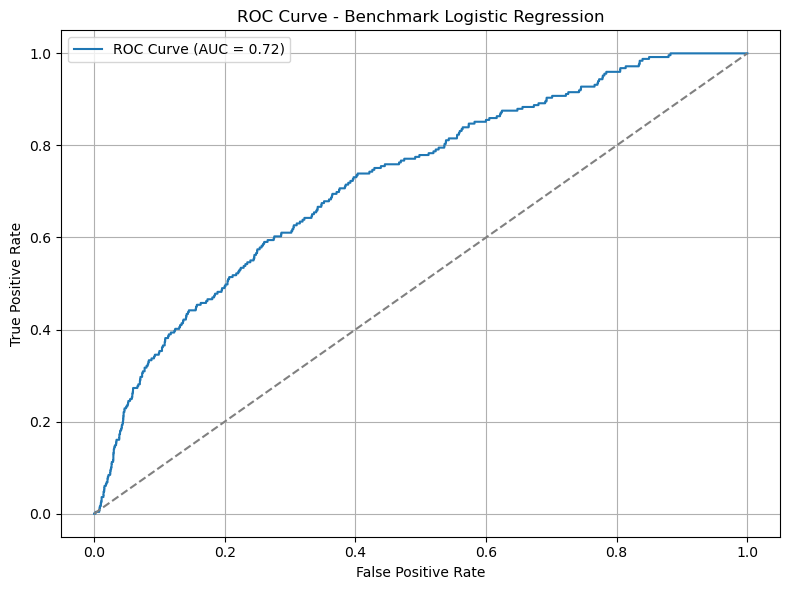

In [66]:

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Pipeline to impute NA's + model
benchmark_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('model', LogisticRegression(max_iter=1000, solver='liblinear', random_state=42))
])

# Fit pipeline model
benchmark_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_benchmark = benchmark_pipeline.predict(X_test)
y_pred_proba = benchmark_pipeline.predict_proba(X_test)[:, 1]

# Evaluation
print(" Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_benchmark))

print("\n Classification Report:")
print(classification_report(y_test, y_pred_benchmark))

print("\n Accuracy Score:")
print(accuracy_score(y_test, y_pred_benchmark))

print("\n ROC AUC Score:")
print(roc_auc_score(y_test, y_pred_proba))

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_score(y_test, y_pred_proba):.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Benchmark Logistic Regression')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [67]:
# Get Model coefficients

model = benchmark_pipeline.named_steps['model']
imputed_X = benchmark_pipeline.named_steps['imputer'].transform(X)

coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0],
    'Odds_Ratio': np.exp(model.coef_[0])
}).sort_values(by='Odds_Ratio', ascending=False)

print("\n Model Summary (Top 10 Features):")
print(coeff_df.head(10))



 Model Summary (Top 10 Features):
                               Feature  Coefficient  Odds_Ratio
122                Vol Range_300 - 449     0.248468    1.282060
86   SUB_TRADE_CHANNEL_PIZZA FAST FOOD     0.190194    1.209484
61   SUB_TRADE_CHANNEL_HOME & HARDWARE     0.165359    1.179816
11             FREQUENT_ORDER_TYPE_EDI     0.142553    1.153214
31      TRADE_CHANNEL_GENERAL RETAILER     0.112072    1.118593
29    TRADE_CHANNEL_FAST CASUAL DINING     0.054323    1.055825
104    Cold Drink Channel_y_BULK TRADE     0.053124    1.054561
111      Cold Drink Channel_BULK TRADE     0.053124    1.054561
16       COLD_DRINK_CHANNEL_BULK TRADE     0.053124    1.054561
97     Cold Drink Channel_x_BULK TRADE     0.053124    1.054561


The ROC-AUC curve for the benchmark model is 0.72, any model we build should perform better than this. We are not considering accuracy as there is a class imbalance due to bias. The accuracy of the model would naturally be biased towards the majority classifier which is the non-growth-ready customer segment. Our benchamark model shows a high accuracy of about 96% which is nothing but the proportion of the majority classifer. 

According to the logistic regression model, Customers whose volume falls under the range of 300-449 and for every gallon increase in this range, the log odds or the probability of the customer being growth-ready increases by about 25% compared to those who are not growth-ready. Similarly, being in the Pizza Fast Food sub-trade channel increases the log odds or the probability of being growth-ready by 19% compared to the reference group, and being in the Home and Hardware sub-trade channel increases the customer's probability of being growth-ready by 16.5% compared to the reference group. Other signficant customer characteristics in increasing the likelihood of being growth-ready are those who use digital ordering platforms, fall under the - general retailer trade-channel, fast casual dining trade-channel, and the bulk trade cold drink channel.

### Random Forest Model

In [72]:
print(X.columns)

Index(['TRANS_COUNT_2023', 'ANNUAL_VOLUME_CASES_2023',
       'ANNUAL_VOLUME_GALLON_2023', 'ANNUAL_VOLUME_2023',
       'AVG_ORDER_VOLUME_2023', 'LOCAL_MARKET_PARTNER', 'CO2_CUSTOMER',
       'ZIP_CODE', 'delivery_cost_2023_case', 'delivery_cost_2023_gallon',
       ...
       'Vol Range_600 - 749', 'Vol Range_750 - 899', 'Vol Range_900 - 1049',
       'Cold Drink Channel_gallon2024_BULK TRADE',
       'Cold Drink Channel_gallon2024_DINING',
       'Cold Drink Channel_gallon2024_EVENT',
       'Cold Drink Channel_gallon2024_GOODS',
       'Cold Drink Channel_gallon2024_PUBLIC SECTOR',
       'Cold Drink Channel_gallon2024_WELLNESS',
       'Cold Drink Channel_gallon2024_WORKPLACE'],
      dtype='object', length=134)


In [73]:
# check for any leakages in the target variable
#print([col for col in X.columns if 'THRESHOLD' in col or 'GROWTH_READY' in col])

Confusion Matrix:
[[5735   55]
 [ 222   27]]

 Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      5790
           1       0.33      0.11      0.16       249

    accuracy                           0.95      6039
   macro avg       0.65      0.55      0.57      6039
weighted avg       0.94      0.95      0.94      6039


 Accuracy Score:
0.9541314787216426


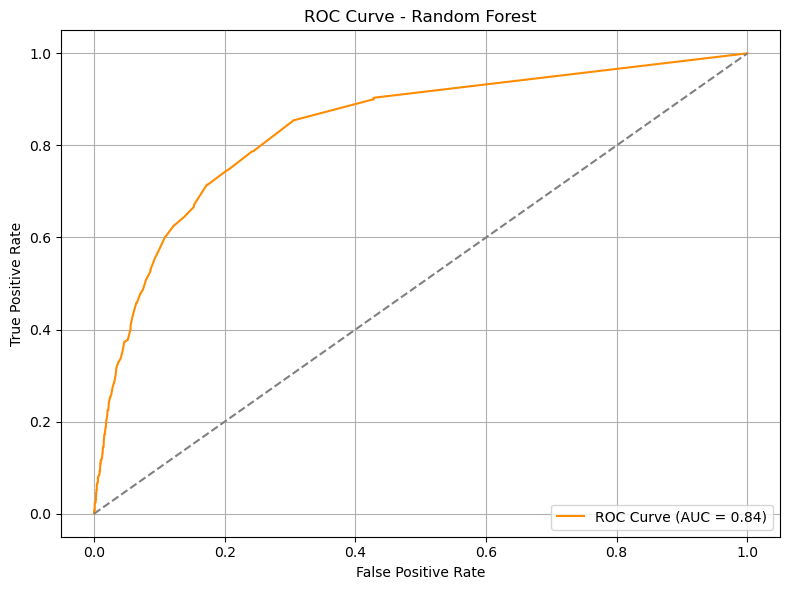

In [74]:

# Define the pipeline: imputation (for NA's) + random forest
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),  # Replace missing values
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Train the model using the pipeline
pipeline.fit(X_train, y_train)

# Predict on test data
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]  # Probabilities for ROC curve

# Evaluate
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\n Classification Report:")
print(classification_report(y_test, y_pred))

print("\n Accuracy Score:")
print(accuracy_score(y_test, y_pred))

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()




 Top 15 Important Features:
                          Feature  Importance
7                        ZIP_CODE    0.223632
4           AVG_ORDER_VOLUME_2023    0.083087
3              ANNUAL_VOLUME_2023    0.078526
10             delivery_cost_2023    0.068902
0                TRANS_COUNT_2023    0.060904
1        ANNUAL_VOLUME_CASES_2023    0.058466
8         delivery_cost_2023_case    0.057179
9       delivery_cost_2023_gallon    0.036656
2       ANNUAL_VOLUME_GALLON_2023    0.036054
6                    CO2_CUSTOMER    0.024959
15  FREQUENT_ORDER_TYPE_SALES REP    0.017929
5            LOCAL_MARKET_PARTNER    0.017079
95                 state_short_MA    0.016035
93                 state_short_KY    0.015796
96                 state_short_MD    0.015081


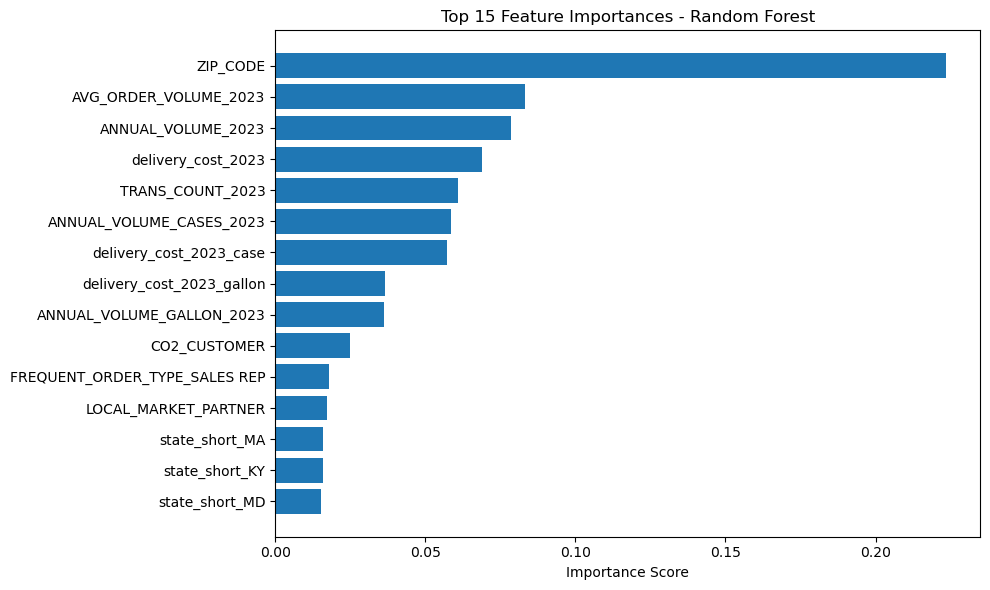

In [76]:
### Which charecteristics drive the predictions

# Extract the trained model from pipeline
rf_model_gs = pipeline.named_steps['classifier']

# Get feature importances
importances = rf_model_gs.feature_importances_

# Map them to feature names
feature_names = X.columns
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

# Show top 15 important features
print(" Top 15 Important Features:")
print(feat_imp_df.head(15))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['Feature'].head(15), feat_imp_df['Importance'].head(15))
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()




### GridSearchCV with Random Forest Classifier

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Confusion Matrix:
[[5735   55]
 [ 222   27]]

 Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      5790
           1       0.33      0.11      0.16       249

    accuracy                           0.95      6039
   macro avg       0.65      0.55      0.57      6039
weighted avg       0.94      0.95      0.94      6039


 Accuracy Score:
0.9541314787216426

 Best Hyperparameters:
{'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}


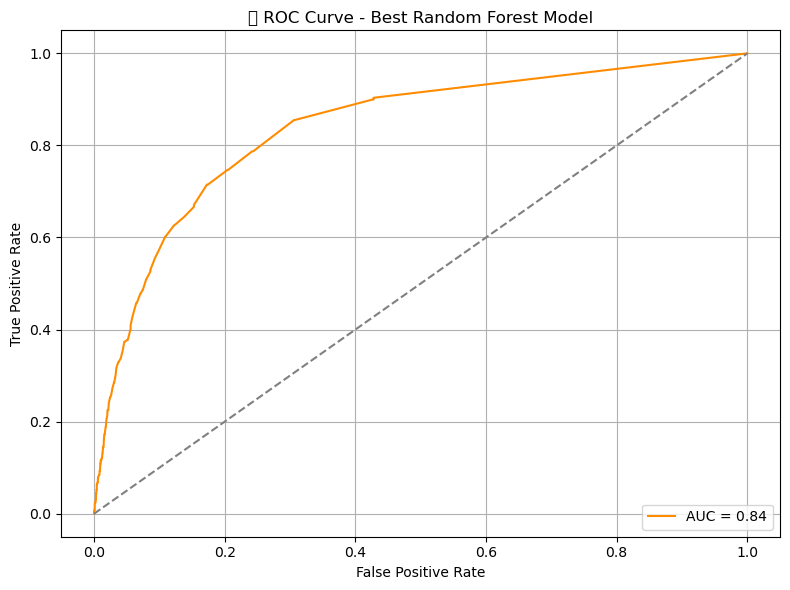

In [81]:

# Define pipeline: impute NA's + RF model
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Define hyperparameter grid 
#(note: prefix with classifier__ to access inside pipeline)
param_grid = {
    'classifier__n_estimators': [50, 100], #no. of trees
    'classifier__max_depth': [None, 5, 10],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2],
    'classifier__max_features': ['sqrt', 'log2']
}

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid,
                           cv=5, scoring='f1', n_jobs=-1, verbose=1)

# Fit model
grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_

# Predict on test set
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]  # get probabilities for class 1 (for ROC-AUC Curve)

# Evaluate
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\n Classification Report:")
print(classification_report(y_test, y_pred))

print("\n Accuracy Score:")
print(accuracy_score(y_test, y_pred))

# Get best parameters
print("\n Best Hyperparameters:")
print(grid_search.best_params_)


# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Compute AUC
roc_auc = roc_auc_score(y_test, y_proba)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}", color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('🚀 ROC Curve - Best Random Forest Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


The ROC-AUC Curve for both the Random Forest model, and the Random Forest model using grid search is 0.84.

the best model was the one with the best hyperparameters:
 Best Hyperparameters:
{'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}

### GradientBoosting(Using XGBoost) with GridSearch

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Confusion Matrix:
[[5774   16]
 [ 227   22]]

 Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      5790
           1       0.58      0.09      0.15       249

    accuracy                           0.96      6039
   macro avg       0.77      0.54      0.57      6039
weighted avg       0.95      0.96      0.95      6039


 Accuracy Score:
0.9597615499254843

 ROC AUC Score: 0.8917


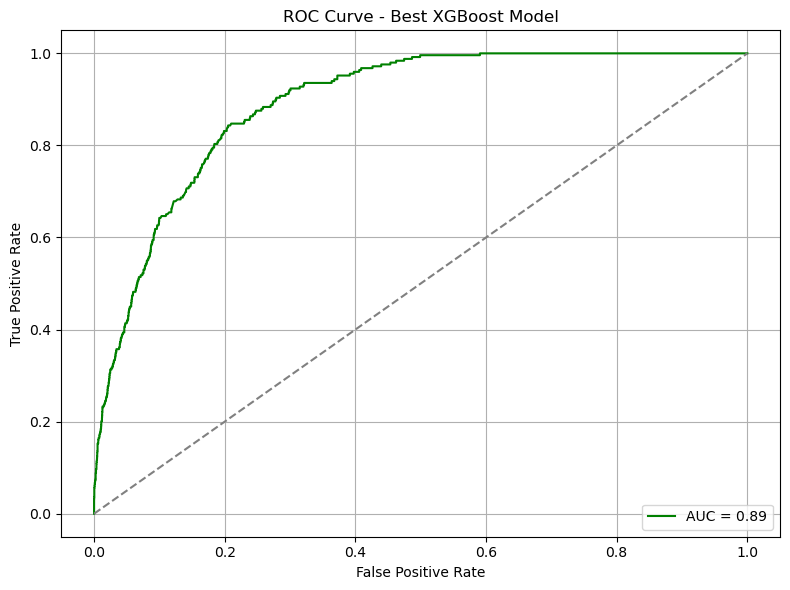

In [93]:

# Define parameter grid for XGBoost
param_grid_xgb = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.02, 0.1],
    'subsample': [0.8, 1.0]
}

# Create xgboost model
xgb_clf = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

# Set up GridSearchCV
grid_search_xgb = GridSearchCV(estimator=xgb_clf, param_grid=param_grid_xgb,
                                cv=5, scoring='f1', verbose=1, n_jobs=-1)

# Fit the model
grid_search_xgb.fit(X_train, y_train)

#  Get the best model
best_xgb = grid_search_xgb.best_estimator_

# Predict on test set from best model
y_pred_xgb = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

# Evaluation Metrics
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\n Classification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\n Accuracy Score:")
print(accuracy_score(y_test, y_pred_xgb))

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_proba_xgb)
print(f"\n ROC AUC Score: {roc_auc:.4f}")

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_xgb)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}", color='green')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Best XGBoost Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()



In [98]:
# Best parameters from XGboost gridsearch

print("\n Best Hyperparameters from GridSearchCV:")
print(grid_search_xgb.best_params_)



 Best Hyperparameters from GridSearchCV:
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}


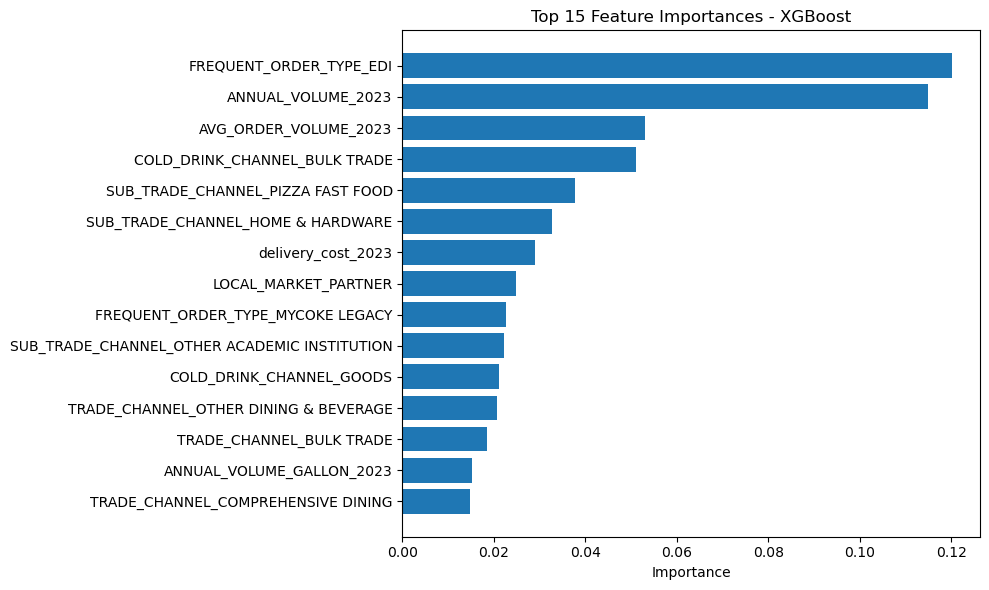

In [99]:
# Feature importance
importances = best_xgb.feature_importances_
feature_names = X.columns
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['Feature'][:15], feat_imp_df['Importance'][:15])
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances - XGBoost')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


Out of the 3 models built, the XGBoost using grid search performed the best with an ROC-AUC of 0.89. The best XGBoost model achieved optimal performance with a learning rate of 0.1, using 100 trees of maximum depth 5.


Customers who frequently use EDI (Electronic Data Interchange) for ordering are strong indicators of growth readiness 
Features like ANNUAL_VOLUME_2023 and AVG_ORDER_VOLUME_2023 indicate that customers with steady (but not necessarily high) volumes and efficient, larger order sizes tend to grow mo e over tim .
Belonging to  Bulk Trade and Pizza/Fast Food, Home/Hardware chains is a strong indicator of growth-readiness t o.
Being a local market partner and having reasonable delivery costs in 2023 also contribute positively to know whether the customer is growth-r.


  


#### Characteristics of customer growth

In [137]:

# Mean values for each group
growth_ready_means = df_model[df_model['GROWTH_READY'] == 1].mean()
non_growth_ready_means = df_model[df_model['GROWTH_READY'] == 0].mean()

comparison = pd.DataFrame({
    'Growth-Ready Mean': growth_ready_means,
    'Non-Growth-Ready Mean': non_growth_ready_means,
    'Difference': growth_ready_means - non_growth_ready_means
})

# Sort by absolute difference
comparison = comparison.reindex(comparison['Difference'].abs().sort_values(ascending=False).index)

# View top features
comparison.head(10)



,Growth-Ready Mean,Non-Growth-Ready Mean,Difference
ANNUAL_VOLUME_2023,172.929993,563.462320,-390.532328
delivery_cost_2023,755.881334,1126.401719,-370.520385
delivery_cost_2023_case,539.799527,843.907541,-304.108014
ANNUAL_VOLUME_CASES_2023,97.513439,392.395366,-294.881927
ZIP_CODE,30150.521319,30272.810335,-122.289015
ANNUAL_VOLUME_GALLON_2023,75.416554,171.066955,-95.650401
delivery_cost_2023_gallon,216.081807,282.494177,-66.412370
TRANS_COUNT_2023,10.140788,17.625851,-7.485062
AVG_ORDER_VOLUME_2023,26.354225,23.942223,2.412003
GROWTH_READY,1.000000,0.000000,1.000000


- Some of the top contributors distinguing growth-ready customers include annual volume, delivery cost, delivery cost by case in 2023. The average 2023 annual volume for growth-ready customers was 172.93 gallons whereas it was 563.46 gallons for those who are not growth-ready. So on average, growth-ready customers started much smaller in terms of volume.


- Their delivery cost was lower in 2023, with an average of 755 dollars, compared to 1126 dollars of non-growth-ready group, suggesting they were smaller accounts of these customers initially. Specifically for cases, the delivery cost of these customers was significantly lower, with an average of 539 dollars as compared to 843 dollars on average for non-growth-ready customers.

- Growth-ready customers also placed slightly larger(26) orders on average, compared to 24 orders on average for those who are non-growth-ready. This also indicates potential for efficiency or better planning.

### Sensitivity Analysis: Obtaining the Best Threshold for Group1 Customers

In [139]:
# Objective function: Composite Score = min cost + high count of high potential customers

# Normalize
sensitivity_df['norm_cost'] = (sensitivity_df['total_cost'] - sensitivity_df['total_cost'].min()) / (sensitivity_df['total_cost'].max() - sensitivity_df['total_cost'].min())
sensitivity_df['norm_high_potential'] = (sensitivity_df['high_potential_customers'] - sensitivity_df['high_potential_customers'].min()) / (sensitivity_df['high_potential_customers'].max() - sensitivity_df['high_potential_customers'].min())

# Define weights
w_cost = 0.5
w_high = 0.5

# Compute composite score (lower is better)
sensitivity_df['composite_score'] = (
    w_cost * sensitivity_df['norm_cost'] + 
    w_high * (1 - sensitivity_df['norm_high_potential'])
)

In [140]:

# Define the range of potential thresholds for sensitivity analysis
threshold_range = range(300, 501, 50)

# Empty lists to store metrics
costs = []        # min cost
high_potential_counts = []   # high no. of high potential customers

# Function to compute both delivery cost and high-potential customer count
def compute_delivery_metrics(threshold):
    df = final_df.copy()

    # Categorize customers based on 2023 and 2024 purchase volume
    df['new_threshold_2023'] = np.where(df['ANNUAL_VOLUME_2023'] >= threshold, 'above', 'below')
    df['new_threshold_2024'] = np.where(df['ANNUAL_VOLUME_2024'] >= threshold, 'above', 'below')

    # Identify high potential customers and growth-ready customers
    df['high_potential'] = np.where(
        ((df['new_threshold_2023'] == 'above') & (df['new_threshold_2024'] == 'above')) |
        ((df['new_threshold_2023'] == 'below') & (df['new_threshold_2024'] == 'above')),
        'high_potential', 'low_potential'
    )

    # Compute delivery costs only for high potential and growth-ready customers
    df['delivery_cost_2023_mod'] = np.where(df['high_potential'] == 'high_potential', df['delivery_cost_2023'], 0)
    df['delivery_cost_2024_mod'] = np.where(df['high_potential'] == 'high_potential', df['delivery_cost_2024'], 0)

    # Total delivery cost
    total_cost = df['delivery_cost_2023_mod'].sum(skipna=True) + df['delivery_cost_2024_mod'].sum(skipna=True)

    # Count of high-potential customers
    high_potential_count = (df['high_potential'] == 'high_potential').sum()

    return total_cost, high_potential_count

# Run metrics for each threshold
for th in threshold_range:
    cost, high_count = compute_delivery_metrics(th)
    costs.append(cost)
    high_potential_counts.append(high_count)

# Create results DataFrame
sensitivity_df = pd.DataFrame({
    'threshold': threshold_range,
    'total_cost': costs,
    'high_potential_customers': high_potential_counts
})

# Normalize the metrics
sensitivity_df['norm_cost'] = (sensitivity_df['total_cost'] - sensitivity_df['total_cost'].min()) / (sensitivity_df['total_cost'].max() - sensitivity_df['total_cost'].min())
sensitivity_df['norm_high_potential'] = (sensitivity_df['high_potential_customers'] - sensitivity_df['high_potential_customers'].min()) / (sensitivity_df['high_potential_customers'].max() - sensitivity_df['high_potential_customers'].min())

# Define weights( tune as per priority)
w_cost = 0.5
w_high = 0.5

# Composite score = lower is better (we reverse high_potential score to reward higher counts)
sensitivity_df['composite_score'] = w_cost * sensitivity_df['norm_cost'] + w_high * (1 - sensitivity_df['norm_high_potential'])

# Get best threshold
best_row = sensitivity_df.loc[sensitivity_df['composite_score'].idxmin()]
optimal_threshold = best_row['threshold']

# Shadow price
sensitivity_df['shadow_price'] = sensitivity_df['total_cost'].diff() / sensitivity_df['threshold'].diff()

# Results
print(" Sensitivity Analysis:")
print(sensitivity_df[['threshold', 'total_cost', 'high_potential_customers', 'composite_score', 'shadow_price']])

print(f"\n Optimal Threshold: {optimal_threshold}")
print("\n  Minimum Composite Score Row:")
print(best_row)

print("\n Maximum Shadow Price:")
print(sensitivity_df.loc[sensitivity_df['shadow_price'].idxmax()])


 Sensitivity Analysis:
   threshold    total_cost  high_potential_customers  composite_score  \
0        300  4.701519e+07                      9841         0.500000   
1        350  4.440534e+07                      8798         0.515774   
2        400  4.175241e+07                      7827         0.518612   
3        450  3.951354e+07                      7081         0.510141   
4        500  3.759439e+07                      6461         0.500000   

   shadow_price  
0           NaN  
1 -52197.135260  
2 -53058.520491  
3 -44777.519784  
4 -38382.943120  

 Optimal Threshold: 300.0

  Minimum Composite Score Row:
threshold                   3.000000e+02
total_cost                  4.701519e+07
high_potential_customers    9.841000e+03
norm_cost                   1.000000e+00
norm_high_potential         1.000000e+00
composite_score             5.000000e-01
Name: 0, dtype: float64

 Maximum Shadow Price:
threshold                   5.000000e+02
total_cost                  3.759439

For all customers—regardless of whether they are local market partners who buy fountain—the optimal threshold to distinguish high-potential customers in both 2023 and 2024 appears to be 300 gallons. If the threshold were lowered from 400 to 300 gallons, the total delivery cost across both years would minimize to approximately $47 million, while also retaining 3,380 more high-potential customers. This would help Swire increase the total number of high-potential customers to 9,841, striking a better balance between cost efficiency and customer growth potential.

# Group2: Analysis on Local Market Partners who only buy Fountain

In [142]:

# Ensure CO2_CUSTOMER and LOCAL_MARKET_PARTNER are converted to boolean
trans_profile_df['CO2_CUSTOMER'] = trans_profile_df['CO2_CUSTOMER'].astype(bool)
trans_profile_df['LOCAL_MARKET_PARTNER'] = trans_profile_df['LOCAL_MARKET_PARTNER'].astype(bool)

# Filter: only Local Market Partners who do NOT purchase cases and only buy gallons
loc_f_df = trans_profile_df[
    (~trans_profile_df['CO2_CUSTOMER']) &
    (trans_profile_df['LOCAL_MARKET_PARTNER']) &
    (trans_profile_df['ANNUAL_VOLUME_CASES_2023'] == 0) &
    (trans_profile_df['ANNUAL_VOLUME_CASES_2024'] == 0)
]

# Summarize total purchases for 2023, 2024, and both years combined
summary = {
    'TOTAL_PURCHASE_2023': loc_f_df['ANNUAL_VOLUME_GALLON_2023'].sum(skipna=True),
    'TOTAL_PURCHASE_2024': loc_f_df['ANNUAL_VOLUME_GALLON_2024'].sum(skipna=True),
    'TOTAL_PURCHASE_2023_2024': (loc_f_df['ANNUAL_VOLUME_GALLON_2023'] + loc_f_df['ANNUAL_VOLUME_GALLON_2024']).sum(skipna=True)
}

# Display summary
pd.DataFrame([summary])



,TOTAL_PURCHASE_2023,TOTAL_PURCHASE_2024,TOTAL_PURCHASE_2023_2024
0,282140.33351,292526.459553,574666.793063


- In 2023, the total annual volume purchased by local market partners who buy fountain is 282140.3 gallons.

- In 2024, the total annual volume purchased by local market partners who buy fountain is 292526.5 gallons.

- A total of 574666.8	gallons in fountain drinks were purchased by local market partners.

In [143]:
# Average annual gallon volume in 2023 and 2024
avg_summary = {
    'AVG_PURCHASE_VOLUME_2023': loc_f_df['ANNUAL_VOLUME_GALLON_2023'].mean(skipna=True),
    'AVG_PURCHASE_VOLUME_2024': loc_f_df['ANNUAL_VOLUME_GALLON_2024'].mean(skipna=True)
}

# Display the result
pd.DataFrame([avg_summary])



,AVG_PURCHASE_VOLUME_2023,AVG_PURCHASE_VOLUME_2024
0,194.982953,202.160649


In [145]:

# Customers with annual gallon volume ≥ 400 in either 2023 or 2024
high_potential_customers = loc_f_df[
    (loc_f_df['ANNUAL_VOLUME_GALLON_2023'] >= 400) | 
    (loc_f_df['ANNUAL_VOLUME_GALLON_2024'] >= 400)
][['CUSTOMER_NUMBER', 'ANNUAL_VOLUME_GALLON_2023', 'ANNUAL_VOLUME_GALLON_2024']]

high_potential_customers.head()




,CUSTOMER_NUMBER,ANNUAL_VOLUME_GALLON_2023,ANNUAL_VOLUME_GALLON_2024
201,500266661,737.5,792.5
211,500267538,730.0,702.5
212,500267539,810.0,792.5
248,500269416,942.5,1002.5
330,500276735,1067.5,992.5


In [144]:
# Summary count of customers above threshold and growth-ready

high_potential_summary = {
    'ABOVE_THRES_2023': (loc_f_df['THRESHOLD_2023'] == 'above').sum(),
    'ABOVE_THRES_2024': (loc_f_df['THRESHOLD_2024'] == 'above').sum(),
    'GROWTH_READY_CUSTOMERS': ((loc_f_df['THRESHOLD_2023'] != 'above') & 
                                (loc_f_df['THRESHOLD_2024'] == 'above')).sum()
}

# Display as a DataFrame
pd.DataFrame([high_potential_summary])



,ABOVE_THRES_2023,ABOVE_THRES_2024,GROWTH_READY_CUSTOMERS
0,200,188,26


- The average annual volume purchased by local market partners buying fountain was about 195 gallons in 2023, and about 202 gallons in 2024.

- 200 customers in this segment appeared to be high volume customers in 2023, and 188 customers appeared to be high volume customers in 2024. 26 customers were found to be growth-ready.

In [159]:
# characteristics of top 10 highest growth customers: only the customers with a drastic increase in purchase rather than threshold (below to above)


# Step 1: Calculate growth in gallons from 2023 to 2024
loc_f_df['GROWTH'] = loc_f_df['ANNUAL_VOLUME_GALLON_2024'] - loc_f_df['ANNUAL_VOLUME_GALLON_2023']

# Step 2: Get the top 10 growth customers
top_10_growth_customers = loc_f_df.sort_values(by='GROWTH', ascending=False).head(10)

# Step 3: Extract their characteristics and growth info
top_10_summary = top_10_growth_customers[[
    'CUSTOMER_NUMBER',
    'ANNUAL_VOLUME_GALLON_2023',
    'ANNUAL_VOLUME_GALLON_2024',
    'GROWTH',
    'COLD_DRINK_CHANNEL',
    'TRADE_CHANNEL',
    'SUB_TRADE_CHANNEL',
    'FREQUENT_ORDER_TYPE',
    'ZIP_CODE'
]]

# Show the result
top_10_summary.reset_index(drop=True, inplace=True)
top_10_summary


,CUSTOMER_NUMBER,ANNUAL_VOLUME_GALLON_2023,ANNUAL_VOLUME_GALLON_2024,GROWTH,COLD_DRINK_CHANNEL,TRADE_CHANNEL,SUB_TRADE_CHANNEL,FREQUENT_ORDER_TYPE,ZIP_CODE
0,501516973,500.0,6565.0,6065.0,DINING,FAST CASUAL DINING,OTHER FAST FOOD,MYCOKE360,1899
1,501579393,0.0,2270.0,2270.0,DINING,COMPREHENSIVE DINING,FSR - MISC,OTHER,42232
2,501676564,0.0,1947.5,1947.5,EVENT,ACTIVITIES,GAME CENTER,SALES REP,1101
3,501457271,4777.5,6110.0,1332.5,DINING,FAST CASUAL DINING,ASIAN FAST FOOD,SALES REP,40526
4,501494585,0.0,770.0,770.0,DINING,LICENSED HOSPITALITY,OTHER LICENSED HOSPITALITY,SALES REP,41385
5,500956234,4417.5,5117.5,700.0,DINING,COMPREHENSIVE DINING,FSR - MISC,SALES REP,40588
6,501569602,132.5,652.5,520.0,DINING,FAST CASUAL DINING,MEXICAN FAST FOOD,CALL CENTER,67213
7,501676506,0.0,515.0,515.0,EVENT,ACTIVITIES,GAME CENTER,SALES REP,1101
8,501628282,0.0,507.5,507.5,DINING,LICENSED HOSPITALITY,OTHER LICENSED HOSPITALITY,SALES REP,66757
9,501396273,0.0,452.5,452.5,DINING,LICENSED HOSPITALITY,OTHER LICENSED HOSPITALITY,SALES REP,1720


- Customer 501516973 showed the highest growth from 2023 to 2024 with an increase in purchase of 6065 gallons of fountain drinks. This customer belongs to DINING cold drink channel and often uses new digital ordering platform (MYCOKE360).